In [1]:
import pandas as pd
import rasterio as ras

In [2]:
df = pd.read_excel("air_samples_Napo.xlsx",sheet_name="Sheet1") #leer la base
df = df[~df["lon"].isna()] #eliminamos los lugares que no conocemos. Mospa fue asumido.


In [3]:
raster_path = "DEM_Ecuador.tif"

with ras.open(raster_path) as src:
    raster_crs = src.crs
    transform = src.transform
    band = src.read(1)


In [4]:
#df["lon"] = df["lon"].astype("Int64")
#df["lat"] = df["lat"].astype("Int64")

#coords = list(zip(df["lon"], df["lat"]))

#with ras.open(raster_path) as src:
 #   df["elev_m"] = [val[0] for val in src.sample(coords)] #añadimos las elevaciones. Tome Papallacta y Oyacachi porque tal vez hubo contaminacion con el aliento.

df

,Unnamed: 0,[CO2],δ13C,δ18O,lat,lon,Site,Elevacion_stm,date,Time,Relation,Unnamed: 11
1,1a,526.464482,-11.763226,21.520575,-2.806333,-78.648532,Sevilla,2490.0,2024-02-09,NaN,-0.022344,NaN
2,1b,483.305255,-10.456225,21.51121,-2.806333,-78.648532,Sevilla,2490.0,2024-02-09,NaN,-0.021635,NaN
3,1c,564.154009,-12.962955,22.080754,-2.806333,-78.648532,Sevilla,2490.0,2024-02-09,NaN,-0.022978,NaN
4,2a,457.092377,-9.446255,20.309781,-3.073683,-79.070943,Irquis,2637.0,2024-02-09,NaN,-0.020666,NaN
5,2b,480.525864,-10.309895,21.63429,-3.073683,-79.070943,Irquis,2637.0,2024-02-09,NaN,-0.021455,NaN
6,2c,458.22814,-9.703522,20.240967,-3.073683,-79.070943,Irquis,2637.0,2024-02-09,NaN,-0.021176,NaN
7,5a,563.476082,-12.896498,22.469205,-0.377203,-78.140765,Papallacta,3141.0,2024-02-11,08:53:00,-0.022887,NaN
8,5b,471.09412,-10.29476,24.105084,-0.377203,-78.140765,Papallacta,3141.0,2024-02-11,08:53:00,-0.021853,NaN
9,5c,454.853558,-9.912013,23.165199,-0.377203,-78.140765,Papallacta,3141.0,2024-02-11,08:53:00,-0.021792,NaN
10,6a,451.405912,-9.740757,23.709178,-0.301828,-78.124128,Oyacachi,3914.0,2024-02-11,10:41:00,-0.021579,NaN


In [5]:
print(df.dtypes)

Unnamed: 0               object
[CO2]                    object
δ13C                     object
δ18O                     object
lat                      object
lon                      object
Site                     object
Elevacion_stm           float64
date             datetime64[ns]
Time                     object
Relation                float64
Unnamed: 11             float64
dtype: object


In [6]:
df['anio'] = df['date'].dt.year
df['CO2'] = pd.to_numeric(df['[CO2]'], errors='coerce')
df['delta13C'] = pd.to_numeric(df['δ13C'], errors='coerce')
#df['hora'] = df['Time'].dt.hour

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  CO2      
No. Observations:   54       Method:              REML     
No. Groups:         19       Scale:               545.8248 
Min. group size:    1        Log-Likelihood:      -259.4188
Max. group size:    4        Converged:           Yes      
Mean group size:    2.8                                    
-----------------------------------------------------------
               Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     505.403   13.810 36.596 0.000 478.336 532.471
Elevacion_stm  -0.010    0.006 -1.830 0.067  -0.022   0.001
Group Var     509.579   12.373                             



NameError: name 'plt' is not defined

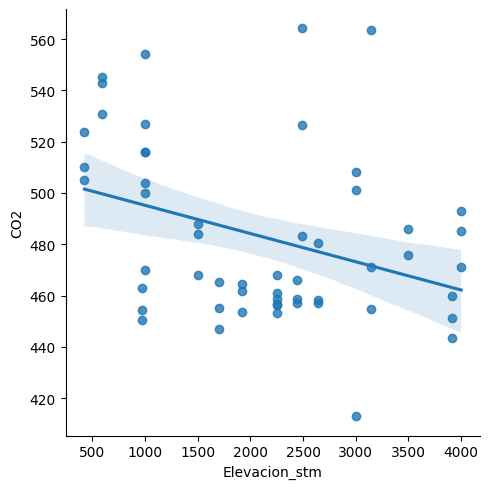

In [9]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib

modelo_co2 = smf.mixedlm(
    'CO2 ~ Elevacion_stm ',data=df,groups=df['Site']
).fit()

print(modelo_co2.summary())

sns.lmplot(
    data=df,
    x='Elevacion_stm',
    y='CO2'
)

plt.show()

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  delta13C
No. Observations:    54       Method:              REML    
No. Groups:          19       Scale:               0.6259  
Min. group size:     1        Log-Likelihood:      -95.0121
Max. group size:     4        Converged:           Yes     
Mean group size:     2.8                                   
-----------------------------------------------------------
               Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-----------------------------------------------------------
Intercept     -10.876    0.939 -11.587 0.000 -12.716 -9.036
Elevacion_stm  -0.000    0.000  -0.266 0.790  -0.001  0.001
Group Var       3.000    1.698                             



NameError: name 'plt' is not defined

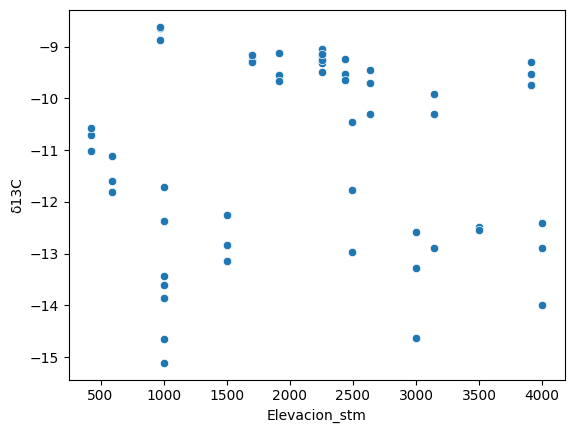

In [14]:
modelo_13C = smf.mixedlm(
    'delta13C ~ Elevacion_stm ',data=df,groups=df['Site']
).fit()

print(modelo_13C.summary())

sns.scatterplot(
    data=df,
    x='Elevacion_stm',
    y='δ13C'
)

plt.show()

In [ ]:
# Hagamos unas medias para usar
#df_medias = df[df["[CO2]"] <= 483].
df_medias = df.groupby(["Site","Elevacion_stm"])["Site","[CO2]","δ13C","δ18O"].mean() #eliminar observaciones muy altas de CO2, y agrupar por sitio
mean_CO2 = df_medias["[CO2]"].mean()
print("el valor medio de CO2 es",mean_CO2)
mean_dC13 = df_medias["δ13C"].mean()
print("el valor medio de d13C es",mean_dC13)


df_medias

el valor medio de CO2 es 482.63658117566393
el valor medio de d13C es -11.11559658069549


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_3836\312443844.py:3: FutureWarning:

Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_3836\312443844.py:3: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



,,[CO2],δ13C,δ18O
Site,Elevacion_stm,,,
Baeza,1917.0,460.048104,-9.445314,21.273141
BoNu,1000.0,532.333333,-13.630000,NaN
CaNu,3000.0,474.000000,-13.496667,NaN
Gal1000,1000.0,497.500000,-13.465000,NaN
Gal1500,1500.0,480.000000,-12.743333,NaN
Guacamayos,2256.0,461.973057,-9.293197,20.994536
Guacamayos entrance,2256.0,456.123009,-9.181697,20.350585
Irquis,2637.0,465.282127,-9.819891,20.728346
Jatun Sacha,426.0,512.878907,-10.770110,21.956140


In [ ]:
# Create the figure (for the moment: a blank graph)
#"""This code creates a cute interactive plot"""
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

variables = ["[CO2]","δ13C","δ18O"]
df = df_medias.reset_index()
for var in variables:
 #interactive_scatterplot(df,var)

 fig = go.Figure()

 # Add the scatter trace
 fig.add_trace(go.Scatter( 
    x=df['Elevacion_stm'], # Variable in the x-axis
    y=df[var], # Variable in the y-axis
    #c=df['Elevacion_stm'],
    mode='markers', 
    hovertext=df['Site'],   # 👈 aquí
    hoverinfo='text+x+y',   # qué mostrar# This explicitly states that we want our observations to be represented by points
    
    # Properties associated with points 
    marker=dict(
        size=12, # Size
        color='#cb1dd1', # Color
        opacity=0.8, # Point transparency 
        line=dict(width=1, color='black') # Properties of the edges
    ),
  ))

 # Customize the layout
 fig.update_layout(
    title='Trends in Elevation', # Title
    xaxis_title='Elevation', # x-axis name
    yaxis_title= var, # y-axis name
    width=800,  # Set the width of the figure to 800 pixels
    height=600,  # Set the height of the figure to 600 pixels
  )

 fig.show()   # 👈 THIS is the key line




In [ ]:
import plotly.express as px


fig = px.scatter(df, x="[CO2]", y="δ13C", color="Elevacion_stm",
                 size='[CO2]', hover_data=['Site'])
fig
#name = "test.html"
#fig.write_html(name)


In [ ]:
import plotly.express as px
from scipy.stats import pearsonr

# Filtrar febrero 2024 si aún no lo hiciste
#df_feb2024 = df[(df['date'] >= '2024-02-01') & (df["date"] < '2024-03-01')].copy()

# Calcular Pearson
r, p = pearsonr(df['Elevacion_stm'], df['δ13C'])

# Crear scatter
fig = px.scatter(
    df,
    x="[CO2]",
    y="δ13C",
    color="Elevacion_stm",
    size='[CO2]',
    hover_data=['Site'],
    title=f"δ13C vs CO2 (Feb 2024) | R = {r:.2f}, p = {p:.3f}"
)

fig.show()

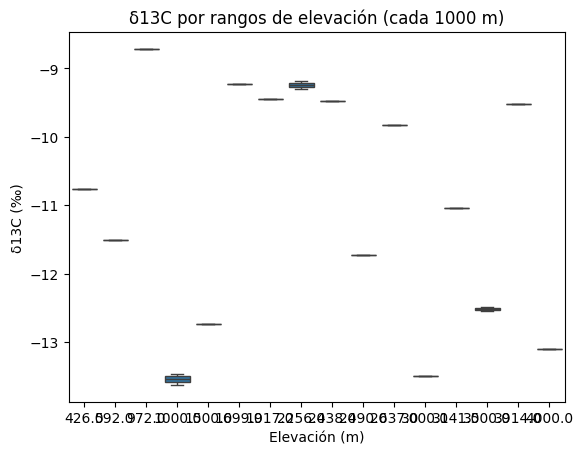

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supongamos que tu dataframe se llama df
# y tiene columnas: 'elevacion' y 'delta13C'

# Asegurar que es datetime

# Filtrar febrero 2024

# Crear bins de 1000 m
#solo Jonachi, Guacamayos y Oyacachi
df['elev_bin'] = (df['Elevacion_stm'] // 1000) * 1000
plt.figure()

sns.boxplot(data=df, x='Elevacion_stm', y='δ13C')

plt.xlabel('Elevación (m)')
plt.ylabel('δ13C (‰)')
plt.title('δ13C por rangos de elevación (cada 1000 m)')

plt.show()